# First Notebook

This first activity will use basic python to load and visualize data. We will:

- Load three datasets — **Bahamian GDP**, **Bahamian nighttime lights**, and the **S&P 500**
- Perform any necessary data cleaning
- Reshape/Resample/Merge as needed
- Calculate basic descriptives
- Plot the data

The data is available in the ```data``` folder.

*Make sure the folder is in the same directory as this notebook.*

This Notebook has **parts** of the code you need to to the tasks above. Follow the notes to complete or write the pieces of code you may need to finish.



In [1]:
# Verify this line runs correctly.
# Otherwise, go to act0_env_check.ipynb

import pandas as pd  # import the pandas library and give it the alias "pd"

Load the GDP data

In [2]:
df_gdp = pd.read_csv('../data/gdp_bs.csv',   # Bahamian real GDP; path is relative to this notebook
                     index_col='date',   # use the 'date' column as the row index instead of 0, 1, 2, ...
                     parse_dates=True)   # convert the index to datetime objects automatically
df_gdp = df_gdp.dropna() # This line drops missing values

df_gdp.rename(columns={'RGDP0000': 'gdp'}, inplace=True)  # rename the column to something shorter
# Observe the data
df_gdp.tail(5)  # show the last 5 rows of the DataFrame

,gdp
date,
2024-06-01,3599.143858
2024-09-01,3445.410889
2024-12-01,3589.903264
2025-03-01,3713.172470
2025-06-01,3692.430050


It has a single series, `gdp` (quarterly, in millions). Select it explicitly — the
double brackets keep the result a **DataFrame** rather than a Series.

In [3]:
df_gdp = df_gdp[['gdp']]
df_gdp.head(5)  # show the first 5 rows of the DataFrame

,gdp
date,
2015-03-01,2978.5
2015-06-01,3060.3
2015-09-01,3033.5
2015-12-01,3001.6
2016-03-01,2963.6


**COMPLETE.**

Load the stock data.

In [4]:
# YOUR CODE HERE: call pd.read_csv(...) with the stock file path, index_col='date', parse_dates=True\
df_stock = pd.read_csv('../data/sp500.csv', index_col='date', parse_dates=True)  # load the stock data into a DataFrame

df_stock.tail(5)  # show the last 5 rows to verify the data loaded correctly

,stock
date,
2026-05-18,7403.05
2026-05-19,7353.61
2026-05-20,7432.97
2026-05-21,7445.72
2026-05-22,7473.47


Open the nighttime lights data: `data/bahamas/blk_ntl.csv`, NASA's **monthly**
cloud-free composite of artificial light over The Bahamas.

In [5]:
df_ntl = pd.read_csv('../data/blk_ntl.csv', index_col='date', parse_dates=True)  # load the nightlights data into a DataFrame

df_ntl.head(10)  # show the first 10 rows (.tail shows last; .head shows first)

,NearNadir_Composite_Snow_Free,DNB_BRDF-Corrected_NTL
date,,
2012-01-01,32854.597789,NaN
2012-02-01,33513.408724,NaN
2012-03-01,35274.971341,NaN
2012-04-01,37540.906971,NaN
2012-05-01,33920.367050,NaN
2012-06-01,37321.873418,NaN
2012-07-01,32979.724072,NaN
2012-08-01,33070.359844,NaN
2012-09-01,31927.562583,NaN


The file has two columns. Keep only `NearNadir_Composite_Snow_Free` — the monthly
composite. The other column is a placeholder and is empty for all but one month.

In [6]:
# Double brackets [[ ]] select a subset of columns and return a DataFrame (single brackets return a Series)
# YOUR CODE HERE: put the column name you want to keep inside the inner brackets,
# e.g. df_ntl[['some_column']]   (the text above tells you which one)
df_ntl = df_ntl[['NearNadir_Composite_Snow_Free']]
df_ntl.head(5)

,NearNadir_Composite_Snow_Free
date,
2012-01-01,32854.597789
2012-02-01,33513.408724
2012-03-01,35274.971341
2012-04-01,37540.906971
2012-05-01,33920.367050


Let's start by visualizing

<Axes: xlabel='date'>

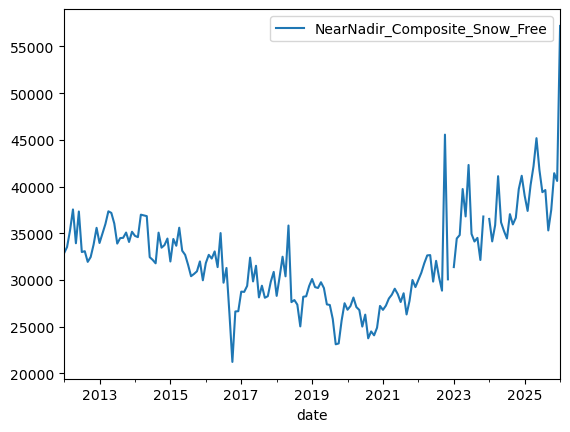

In [7]:
# YOUR CODE HERE: call .plot() on df_ntl to visualize the series.
df_ntl.plot()

Notice the three series are on **three different frequencies**: the lights are
monthly, GDP is quarterly, and the stock index is daily. Series cannot be merged
until they share a frequency, and the slowest one — GDP — decides it.

Resample the lights down to quarterly.

**COMPLETE**: **QS** standds for Quarter Start. **QE** for Quarter End.

In [8]:
# YOUR CODE HERE: pass a frequency string inside resample(), e.g. resample('QS') for Quarter Start
# .mean() then averages all monthly values that fall within each quarter
df_ntl = df_ntl.resample('QS').mean()
df_ntl.tail(10)

,NearNadir_Composite_Snow_Free
date,
2023-10-01,34457.643159
2024-01-01,35501.743653
2024-04-01,37497.945658
2024-07-01,35803.286942
2024-10-01,39173.626551
2025-01-01,38846.469407
2025-04-01,43040.397998
2025-07-01,38102.951229
2025-10-01,39839.346837


You will notice your data has many missing values because GDP finishes in 2023 but the stock index runs to 2026. Let's keep only the columns where there are no missing values.

In [9]:
# dropna removes rows with missing values (NaN)
# how='all' means: only drop a row if ALL its columns are NaN (keeps rows missing just one value)
# axis=0 means operate on rows (axis=1 would operate on columns)
df_ntl = df_ntl.dropna(how='all', axis=0)
df_ntl.tail(10)

,NearNadir_Composite_Snow_Free
date,
2023-10-01,34457.643159
2024-01-01,35501.743653
2024-04-01,37497.945658
2024-07-01,35803.286942
2024-10-01,39173.626551
2025-01-01,38846.469407
2025-04-01,43040.397998
2025-07-01,38102.951229
2025-10-01,39839.346837


Descriptive statistics here

In [10]:
df_ntl.describe()  # returns count, mean, std, min, quartiles, and max for each numeric column

,NearNadir_Composite_Snow_Free
count,57.000000
mean,32668.470473
std,5425.499632
min,24821.713096
25%,28934.330651
50%,32659.215500
75%,35387.389319
max,57200.455668


**COMPLETE**: Can we plot again?

<Axes: xlabel='date'>

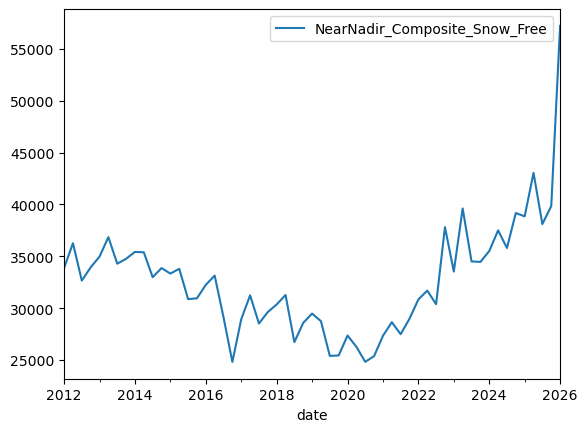

In [11]:
# YOUR CODE HERE: call .plot()
df_ntl.plot()

# Merge data

We have 3 series

(<Axes: xlabel='date'>, <Axes: xlabel='date'>, <Axes: xlabel='date'>)

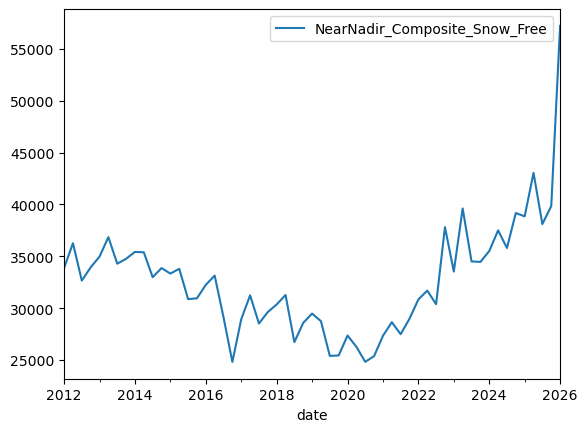

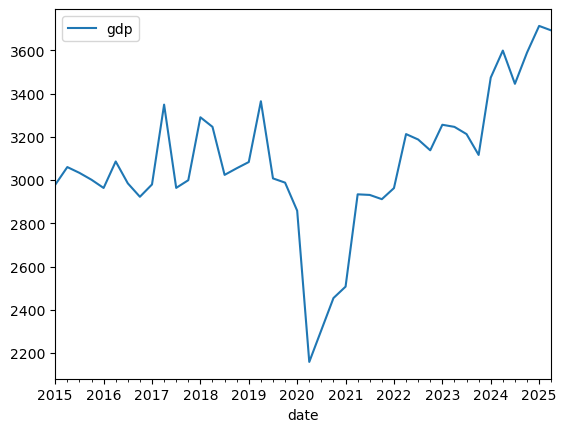

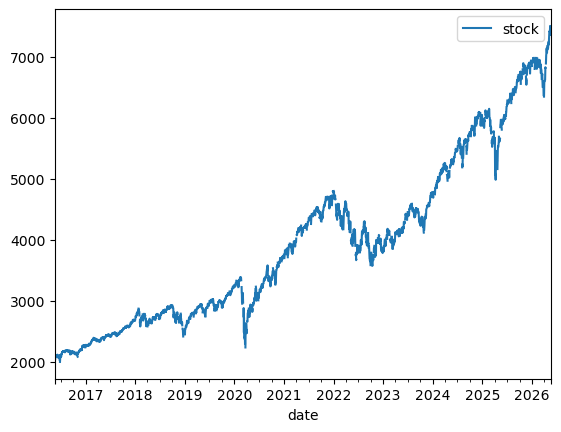

In [12]:
# Calling .plot() on each DataFrame opens a separate chart for each series
# Expressions separated by commas inside a cell return a tuple of results — each plot displays inline
df_ntl.plot(), df_gdp.plot(), df_stock.plot()

Resample stock data into quarters

In [13]:
df_stock = df_stock.resample('QS').mean()  # group daily/monthly data into quarters (Quarter Start) and average
df_stock.tail(10)

,stock
date,
2024-01-01,4992.540984
2024-04-01,5246.626508
2024-07-01,5543.469219
2024-10-01,5907.042969
2025-01-01,5894.817833
2025-04-01,5732.060484
2025-07-01,6427.738750
2025-10-01,6777.567187
2026-01-01,6819.048852


Now merge, but...

In [17]:
# .merge() joins two DataFrames — like a SQL JOIN
# left_index=True, right_index=True means use the row index (date) as the join key on both sides
df_merge = df_ntl.merge(df_gdp, left_index=True, right_index=True)
df_merge = df_merge.merge(df_stock, left_index=True, right_index=True)  # chain a second merge onto the result
df_merge

,NearNadir_Composite_Snow_Free,gdp,stock
date,,,


It's not working. This is a common problem. The date indexes do not align. Look at GDP again:

In [14]:
df_gdp.tail(5)

,gdp
date,
2024-06-01,3599.143858
2024-09-01,3445.410889
2024-12-01,3589.903264
2025-03-01,3713.172470
2025-06-01,3692.430050


In [15]:
df_stock.tail(5)

,stock
date,
2025-04-01,5732.060484
2025-07-01,6427.738750
2025-10-01,6777.567187
2026-01-01,6819.048852
2026-04-01,7139.595135


In [16]:
df_ntl.tail(5)

,NearNadir_Composite_Snow_Free
date,
2025-01-01,38846.469407
2025-04-01,43040.397998
2025-07-01,38102.951229
2025-10-01,39839.346837
2026-01-01,57200.455668


GDP is stamped at the **start of the last month** of each quarter (1 Mar, 1, Jun)
while `resample('QS')` gave the other two the **start** (1 Jan, 1 Apr, …). Several fixes exist — you could
resample GDP to `QS` or move the other dates to the last month of the quarter.

In [20]:
df_gdp = df_gdp.resample('QS').mean()

In [21]:
# Now that the date indexes match, the merge should produce non-empty rows
df_merge = df_ntl.merge(df_gdp, left_index=True, right_index=True)
df_merge = df_merge.merge(df_stock, left_index=True, right_index=True)
df_merge

,NearNadir_Composite_Snow_Free,gdp,stock
date,,,
2016-04-01,33141.232204,3086.200000,2083.798929
2016-07-01,29123.867345,2985.100000,2162.056875
2016-10-01,24821.713096,2922.900000,2184.878571
2017-01-01,28934.330651,2979.900000,2325.927903
2017-04-01,31240.284136,3349.100000,2397.970952
2017-07-01,28524.307921,2964.000000,2467.174603
2017-10-01,29631.425053,2999.600000,2603.277302
2018-01-01,30361.242792,3290.600000,2733.476721
2018-04-01,31271.058498,3246.300000,2703.131250


Plot

<Axes: xlabel='date'>

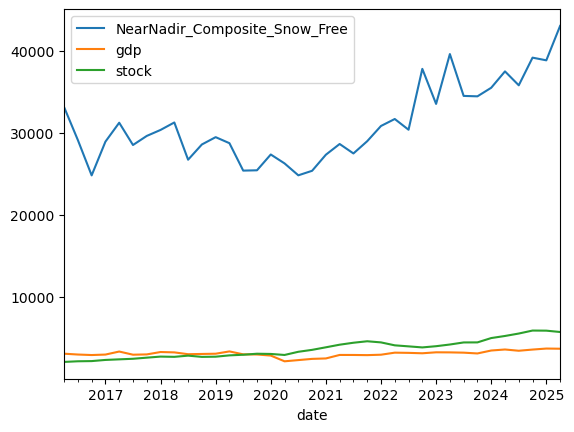

In [22]:
df_merge.plot()

Yes, but we may want to make the comparison meaningful. Let's normalize both series to the QoQ rate of change.

In [23]:
df_change = df_merge.pct_change()  # compute period-over-period percentage change: (current - previous) / previous
df_change.head(5)  # first row will be NaN because there is no previous value to compare against

,NearNadir_Composite_Snow_Free,gdp,stock
date,,,
2016-04-01,NaN,NaN,NaN
2016-07-01,-0.121220,-0.032759,0.037555
2016-10-01,-0.147719,-0.020837,0.010556
2017-01-01,0.165686,0.019501,0.064557
2017-04-01,0.079696,0.123897,0.030974


Plot

<Axes: xlabel='date'>

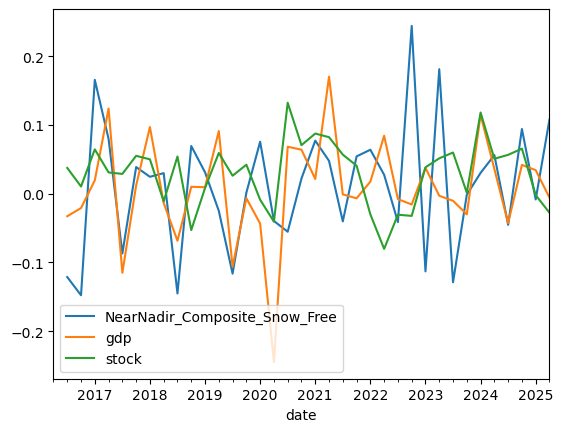

In [24]:
df_change.plot()